In [3]:
pip install numpy pandas scipy seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\Ravi Gupta\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import (
    gmean,
    hmean,
    trim_mean,
    norm,
    expon,
    poisson,
    ttest_ind,
    ttest_rel,
    chi2_contingency,
    f_oneway
)

In [5]:
#1. Generate 100 integers between 90 and 130
np.random.seed(42)

int_list = np.random.randint(90, 131, 100)

print(int_list)
print("Number of values:", len(int_list))

[128 118 104  97 110 128 108 112 100 100 113 125 129 113  92 111  91 113
 119 127  91 110 122 101 111 114 116 117 105 104  92 126  96 110  98 128
 107  93 114 103  98 115  91 109 117  96  97 124 103 106 125 129  93  91
  95  93 118 107 115 123  99 125 103 120 104  97 103 112 129 110 105 107
 113 115 114 130 118 104  90 114  96  98 113  90  97 113 100 106  97 124
 124 122  94 128 130 117  96  98  97 101]
Number of values: 100


In [6]:
#(i) Mean
def calculate_mean(data):
    return sum(data) / len(data)

print("Mean:", calculate_mean(int_list))

Mean: 108.94


In [7]:
#Median
def calculate_median(data):
    sorted_data = sorted(data)
    n = len(sorted_data)

    if n % 2 == 0:
        return (sorted_data[n//2 - 1] + sorted_data[n//2]) / 2
    else:
        return sorted_data[n//2]

print("Median:", calculate_median(int_list))

Median: 109.5


In [8]:
#(ii) Mode
from collections import Counter

def calculate_mode(data):
    frequency = Counter(data)
    max_frequency = max(frequency.values())

    modes = [
        value for value, count in frequency.items()
        if count == max_frequency
    ]

    return modes

print("Mode:", calculate_mode(int_list))

Mode: [np.int32(97), np.int32(113)]


In [9]:
#(iii) Weighted Mean
def weighted_mean(values, weights):
    return sum(
        value * weight
        for value, weight in zip(values, weights)
    ) / sum(weights)

values = [10, 20, 30, 40]
weights = [1, 2, 3, 4]

print("Weighted Mean:", weighted_mean(values, weights))

Weighted Mean: 30.0


In [10]:
#(iv) Geometric Mean
def geometric_mean(data):
    product = 1

    for value in data:
        product *= value

    return product ** (1 / len(data))

positive_data = [2, 4, 8, 16]

print("Geometric Mean:", geometric_mean(positive_data))

Geometric Mean: 5.656854249492381


In [11]:
#(v) Harmonic Mean
def harmonic_mean(data):
    return len(data) / sum(1 / x for x in data)

data = [2, 4, 8, 16]

print("Harmonic Mean:", harmonic_mean(data))

Harmonic Mean: 4.266666666666667


In [14]:
#(vi) Midrange

def midrange(data):
    return (min(data) + max(data)) / 2

print("Midrange:", midrange(int_list))

Midrange: 110.0


In [15]:
#(vii) Trimmed Mean

def calculate_trimmed_mean(data, percentage=10):
    data = sorted(data)

    n = len(data)
    trim_count = int(n * percentage / 100)

    trimmed_data = data[trim_count:n-trim_count]

    return sum(trimmed_data) / len(trimmed_data)

print("Trimmed Mean:", calculate_trimmed_mean(int_list, 10))

Trimmed Mean: 108.675


In [16]:
#2. Generate 500 integers between 200 and 300
np.random.seed(42)

int_list2 = np.random.randint(200, 301, 500)

print(int_list2)
print("Number of values:", len(int_list2))

[251 292 214 271 260 220 282 286 274 274 287 299 223 202 221 252 201 287
 229 237 201 263 259 220 232 275 257 221 288 248 290 258 241 291 259 279
 214 261 261 246 261 250 254 263 202 300 250 206 220 272 238 217 203 288
 259 213 208 289 252 201 283 291 259 270 243 207 246 234 277 280 235 249
 203 201 205 253 203 253 292 262 217 289 243 233 273 261 299 213 294 247
 214 271 277 286 261 239 284 279 281 252 223 225 288 259 240 228 214 244
 264 288 270 208 287 200 207 287 262 210 280 207 234 234 232 204 240 227
 206 272 271 211 233 232 247 222 261 287 236 298 243 285 290 234 264 298
 300 246 277 202 200 204 289 213 226 208 278 214 289 241 276 250 262 295
 251 295 203 293 300 222 214 242 228 235 212 231 270 258 285 227 265 241
 244 261 256 205 227 227 243 283 229 261 274 291 288 261 296 200 226 261
 276 202 269 271 226 208 261 236 296 250 243 223 278 258 231 295 287 251
 261 257 251 211 238 201 202 300 255 280 258 201 201 291 253 286 300 295
 296 200 218 201 252 243 289 231 269 231 267 254 27

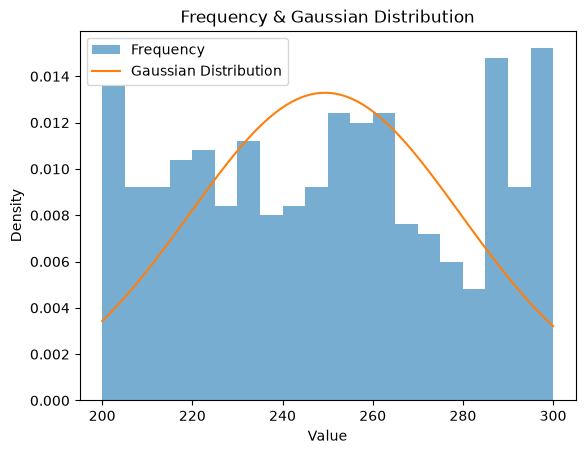

In [17]:
#2(i). Frequency & Gaussian Distribution
mean = np.mean(int_list2)
std = np.std(int_list2)

plt.hist(
    int_list2,
    bins=20,
    density=True,
    alpha=0.6,
    label="Frequency"
)

x = np.linspace(min(int_list2), max(int_list2), 500)

gaussian = norm.pdf(
    x,
    mean,
    std
)

plt.plot(
    x,
    gaussian,
    label="Gaussian Distribution"
)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Frequency & Gaussian Distribution")
plt.legend()
plt.show()

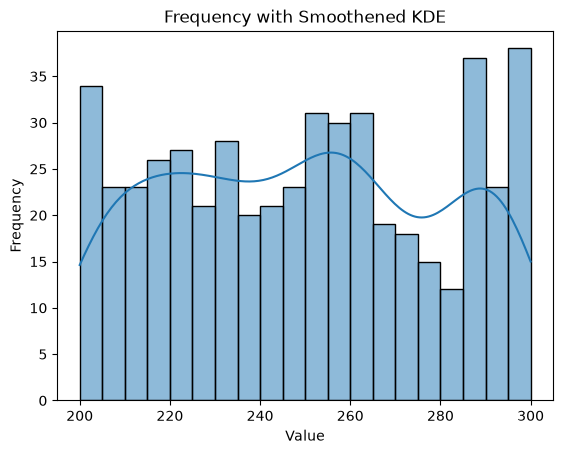

In [18]:
#2(i). Frequency Smoothened KDE
sns.histplot(
    int_list2,
    kde=True,
    bins=20
)

plt.title("Frequency with Smoothened KDE")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

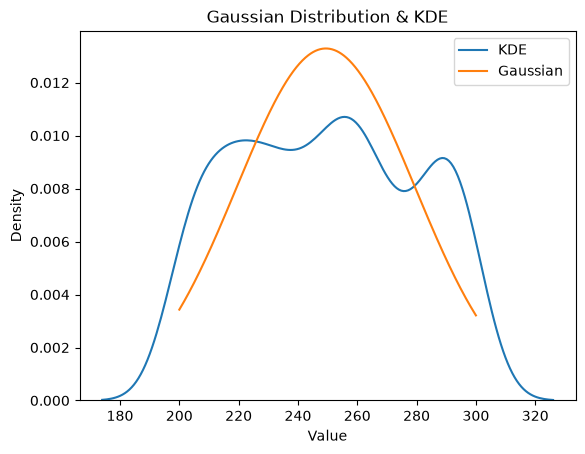

In [19]:
#2(i). Gaussian + KDE
sns.kdeplot(
    int_list2,
    label="KDE"
)

x = np.linspace(
    min(int_list2),
    max(int_list2),
    500
)

plt.plot(
    x,
    norm.pdf(x, np.mean(int_list2), np.std(int_list2)),
    label="Gaussian"
)

plt.title("Gaussian Distribution & KDE")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

In [20]:
#2(ii). Range
def calculate_range(data):
    return max(data) - min(data)

print("Range:", calculate_range(int_list2))

Range: 100


In [21]:
#2(iii). Variance and Standard Deviation
def calculate_variance(data):
    mean = sum(data) / len(data)

    return sum(
        (x - mean) ** 2
        for x in data
    ) / len(data)


def calculate_std(data):
    return calculate_variance(data) ** 0.5


print("Variance:", calculate_variance(int_list2))
print("Standard Deviation:", calculate_std(int_list2))

Variance: 901.3499000000006
Standard Deviation: 30.022489903404093


In [22]:
#2(iv). Interquartile Range
def calculate_iqr(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    return q3 - q1

print("IQR:", calculate_iqr(int_list2))

IQR: 51.25


In [23]:
#2(v). Coefficient of Variation

def coefficient_of_variation(data):
    mean = np.mean(data)
    std = np.std(data)

    return (std / mean) * 100

print("Coefficient of Variation:",
      coefficient_of_variation(int_list2), "%")

Coefficient of Variation: 12.037404235357076 %


In [24]:
#2(vi). Mean Absolute Deviation
def mean_absolute_deviation(data):
    mean = np.mean(data)

    return np.mean(
        [abs(x - mean) for x in data]
    )

print(
    "Mean Absolute Deviation:",
    mean_absolute_deviation(int_list2)
)

Mean Absolute Deviation: 25.803440000000002


In [25]:
#2(vii). Quartile Deviation


def quartile_deviation(data):
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)

    return (q3 - q1) / 2

print("Quartile Deviation:",
      quartile_deviation(int_list2))

Quartile Deviation: 25.625


In [26]:
#2(viii). Range-based Coefficient of Dispersion


def range_based_coefficient(data):
    maximum = max(data)
    minimum = min(data)

    return (maximum - minimum) / (maximum + minimum)

print(
    "Range-based Coefficient of Dispersion:",
    range_based_coefficient(int_list2)
)

Range-based Coefficient of Dispersion: 0.2


In [27]:
#3. Write a Python class representing a discrete random variable with methods to calculate its expected value and variance.
class DiscreteRandomVariable:

    def __init__(self, values, probabilities):
        self.values = np.array(values)
        self.probabilities = np.array(probabilities)

    def expected_value(self):
        return np.sum(
            self.values * self.probabilities
        )

    def variance(self):
        mean = self.expected_value()

        return np.sum(
            ((self.values - mean) ** 2)
            * self.probabilities
        )


values = [1, 2, 3, 4, 5, 6]
probabilities = [1/6] * 6

rv = DiscreteRandomVariable(
    values,
    probabilities
)

print("Expected Value:", rv.expected_value())
print("Variance:", rv.variance())

Expected Value: 3.5
Variance: 2.9166666666666665


In [28]:
#4.  Implement a program to simulate the rolling of a fair six-sided die and calculate the expected value and variance of the outcomes
np.random.seed(42)

outcomes = np.random.randint(
    1,
    7,
    10000
)

print("Expected Value:", np.mean(outcomes))
print("Variance:", np.var(outcomes))

Expected Value: 3.4999
Variance: 2.91939999


In [29]:
#5. Create a Python function to generate random samples from a given probability distribution (e.g.,
#binomial, Poisson) and calculate their mean and variance.
binomial_samples = np.random.binomial(
    n=10,
    p=0.5,
    size=1000
)

print("Binomial Mean:", np.mean(binomial_samples))
print("Binomial Variance:", np.var(binomial_samples))

Binomial Mean: 5.022
Binomial Variance: 2.5035159999999994


In [30]:
#6. Write a Python script to generate random numbers from a Gaussian (normal) distribution and compute
#the mean, variance, and standard deviation of the samples
np.random.seed(42)

samples = np.random.normal(
    loc=0,
    scale=1,
    size=1000
)

print("Mean:", np.mean(samples))
print("Variance:", np.var(samples))
print("Standard Deviation:", np.std(samples))

Mean: 0.01933205582232549
Variance: 0.9579049897315173
Standard Deviation: 0.9787262077473543


In [31]:
#7.  Write a Python function to calculate the probability density function (PDF) of a continuous random variable for a given normal distribution.
def normal_pdf(x, mean, std):
    coefficient = 1 / (
        std * np.sqrt(2 * np.pi)
    )

    exponent = np.exp(
        -0.5 * ((x - mean) / std) ** 2
    )

    return coefficient * exponent


x = 0
mean = 0
std = 1

print("PDF:", normal_pdf(x, mean, std))

PDF: 0.3989422804014327


In [32]:
#8. Create a program to calculate the cumulative distribution function (CDF) of exponential distribution
def exponential_cdf(x, rate):
    return 1 - np.exp(-rate * x)

x = 2
rate = 0.5

print("CDF:", exponential_cdf(x, rate))

CDF: 0.6321205588285577


In [34]:
#9. Write a Python function to calculate the probability mass function (PMF) of Poisson distribution.


import math

def poisson_pmf(k, lam):
    return (
        np.exp(-lam)
        * lam**k
        / math.factorial(k)
    )

k = 3
lam = 4

print("Poisson PMF:", poisson_pmf(k, lam))

Poisson PMF: 0.19536681481316456


In [35]:
# Use seaborn library to load tips dataset. Find the following from the dataset for the columns total_bill and tip`:

tips = sns.load_dataset("tips")

print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [36]:
#(i) Skewness
def calculate_skewness(data):
    return data.skew()

print(
    "Total Bill Skewness:",
    calculate_skewness(tips["total_bill"])
)

print(
    "Tip Skewness:",
    calculate_skewness(tips["tip"])
)

Total Bill Skewness: 1.1332130376158205
Tip Skewness: 1.4654510370979401


In [37]:
#(ii) Determine skewness type
def skewness_type(skewness):

    if skewness > 0.5:
        return "Positive Skewness"

    elif skewness < -0.5:
        return "Negative Skewness"

    else:
        return "Approximately Symmetric"


for column in ["total_bill", "tip"]:

    skew = tips[column].skew()

    print(
        column,
        "→",
        skewness_type(skew)
    )

total_bill → Positive Skewness
tip → Positive Skewness


In [55]:
# Q7 (iii)Write a function that calculates the covariance between two columns.
def calculate_covariance(x, y):

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    return np.sum(
        (x - x_mean) * (y - y_mean)
    ) / (len(x) - 1)


covariance = calculate_covariance(
    tips["total_bill"],
    tips["tip"]
)

print("Covariance:", covariance)

Covariance: 8.323501629224852


In [56]:
# Q7 (iv) Implement a Python program that calculates the Pearson correlation coefficient between two columns
def pearson_correlation(x, y):

    return np.corrcoef(x, y)[0, 1]


correlation = pearson_correlation(
    tips["total_bill"],
    tips["tip"]
)

print("Pearson Correlation:", correlation)

Pearson Correlation: 0.6757341092113645


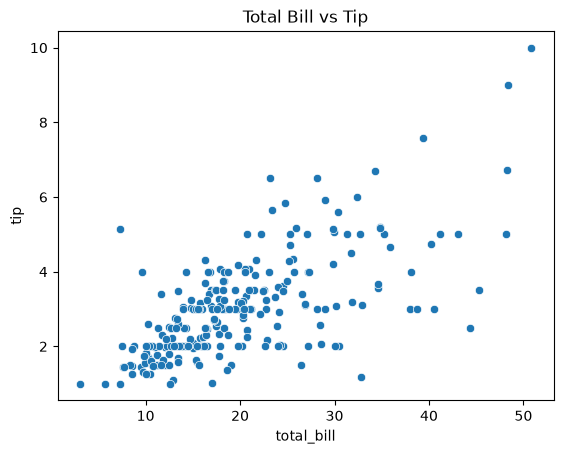

In [57]:
# Q7  (v) Write a script to visualize the correlation between two specific columns in a Pandas DataFrame usingscatter plots..
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip"
)

plt.title("Total Bill vs Tip")
plt.show()

In [42]:
# Q12. A tutoring service claims that its program improves students' exam scores. A sample of students who
#participated in the program was taken, and their scores before and after the program were recorded. before_program = np.array([
    75, 80, 85, 70, 90,
    78, 92, 88, 82, 87
])

after_program = np.array([
    80, 85, 90, 80, 92,
    80, 95, 90, 85, 88
])

differences = after_program - before_program

z_stat = np.mean(differences) / (
    np.std(differences, ddof=1) /
    np.sqrt(len(differences))
)

p_value = 2 * (
    1 - norm.cdf(abs(z_stat))
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 4.593190894944668
P-value: 4.365194105293568e-06


In [43]:
#13. A pharmaceutical company wants to determine if a new drug is effective in reducing blood pressure. They
#conduct a study and record blood pressure measurements before and after administering the drug. before_drug = np.array([
    145, 150, 140, 135, 155,
    160, 152, 148, 130, 138
])

after_drug = np.array([
    130, 140, 132, 128, 145,
    148, 138, 136, 125, 130
])

differences = before_drug - after_drug

z_stat = np.mean(differences) / (
    np.std(differences, ddof=1)
    / np.sqrt(len(differences))
)

p_value = 2 * (
    1 - norm.cdf(abs(z_stat))
)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: 10.049875621120888
P-value: 0.0


In [44]:
#14. A customer service department claims that their average response time is less than 5 minutes. A sample
#of recent customer interactions was taken, and the response times were recorded.

response_times = np.array([
    4.3, 3.8, 5.1, 4.9, 4.7,
    4.2, 5.2, 4.5, 4.6, 4.4
])

population_mean = 5

z_stat = (
    np.mean(response_times)
    - population_mean
) / (
    np.std(response_times, ddof=1)
    / np.sqrt(len(response_times))
)

p_value = norm.cdf(z_stat)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -3.184457226042963
P-value: 0.0007251287113068958


In [45]:
#15. A company is testing two different website layouts to see which one leads to higher click-through rates.
#Write a Python function to perform an A/B test analysis, including calculating the t-statistic, degrees of freedom, and p-value 


layout_a_clicks = [
    28, 32, 33, 29, 31,
    34, 30, 35, 36, 37
]

layout_b_clicks = [
    40, 41, 38, 42, 39,
    44, 43, 41, 45, 47
]

t_stat, p_value = ttest_ind(
    layout_a_clicks,
    layout_b_clicks,
    equal_var=False
)

df = len(layout_a_clicks) + len(layout_b_clicks) - 2

print("T-statistic:", t_stat)
print("Degrees of Freedom:", df)
print("P-value:", p_value)

T-statistic: -7.298102156175069
Degrees of Freedom: 18
P-value: 9.196596070789399e-07


In [46]:
# Q16. A pharmaceutical company wants to determine if a new drug is more effective than an existing drug in
#reducing cholesterol levels. Create a program to analyze the clinical trial data and calculate the tstatistic and p-value for the treatment effect.
#existing_drug_levels = [
    180, 182, 175, 185, 178,
    176, 172, 184, 179, 183
]

new_drug_levels = [
    170, 172, 165, 168, 175,
    173, 170, 178, 172, 176
]

t_stat, p_value = ttest_ind(
    existing_drug_levels,
    new_drug_levels,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 4.140480986208659
P-value: 0.0006229228945469327


In [47]:
#17. A school district introduces an educational intervention program to improve math scores. Write a Python
#function to analyze pre- and post-intervention test scores, calculating the t-statistic and p-value to
#determine if the intervention had a significant impact.
#pre_intervention_scores = [
    80, 85, 90, 75, 88,
    82, 92, 78, 85, 87
]

post_intervention_scores = [
    90, 92, 88, 92, 95,
    91, 96, 93, 89, 93
]

t_stat, p_value = ttest_rel(
    pre_intervention_scores,
    post_intervention_scores
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -4.42840883965761
P-value: 0.0016509548165795497


In [48]:
#18. An HR department wants to investigate if there's a gender-based salary gap within the company. Develop
#a program to analyze salary data, calculate the t-statistic, and determine if there's a statistically
#significant difference between the average salaries of male and female employees.
#np.random.seed(0)

male_salaries = np.random.normal(
    loc=50000,
    scale=10000,
    size=20
)

female_salaries = np.random.normal(
    loc=55000,
    scale=9000,
    size=20
)

t_stat, p_value = ttest_ind(
    male_salaries,
    female_salaries,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.061142089696313844
P-value: 0.9515826849267928


In [49]:
# Q19. A manufacturer produces two different versions of a product and wants to compare their quality scores.
#Create a Python function to analyze quality assessment data, calculate the t-statistic, and decide
#whether there's a significant difference in quality between the two versions
#version1_scores = [
    85, 88, 82, 89, 87,
    84, 90, 88, 85, 86,
    91, 83, 87, 84, 89,
    86, 84, 88, 85, 86,
    89, 90, 87, 88, 85
]

version2_scores = [
    80, 78, 83, 81, 79,
    82, 76, 80, 78, 81,
    77, 82, 80, 79, 82,
    79, 80, 81, 79, 82,
    79, 78, 80, 81, 82
]

t_stat, p_value = ttest_ind(
    version1_scores,
    version2_scores,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 11.325830417646698
P-value: 1.0787540843781544e-14


In [50]:
#20. A restaurant chain collects customer satisfaction scores for two different branches. Write a program to
#analyze the scores, calculate the t-statistic, and determine if there's a statistically significant difference in
#customer satisfaction between the branches.
branch_a_scores = [
    4, 5, 3, 4, 5, 4, 5, 3,
    4, 4, 5, 4, 4, 3, 4, 5,
    5, 4, 3, 4, 5, 4, 3, 5,
    4, 4, 5, 3, 4, 5, 4
]

branch_b_scores = [
    3, 4, 2, 3, 4, 3, 4, 2,
    3, 3, 4, 3, 3, 2, 3, 4,
    4, 3, 2, 3, 4, 3, 2, 4,
    3, 3, 4, 2, 3, 4, 3
]

t_stat, p_value = ttest_ind(
    branch_a_scores,
    branch_b_scores,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 5.480077554195743
P-value: 8.895290509945674e-07


In [51]:
#24. A political analyst wants to determine if there is a significant association between age groups and voter
#preferences (Candidate A or Candidate B). They collect data from a sample of 500 voters and classify
#them into different age groups and candidate preferences. Perform a Chi-Square test to determine if
#there is a significant association between age groups and voter preferences.

np.random.seed(0)

age_groups = np.random.choice(
    ['18-30', '31-50', '51+'],
    size=30
)

voter_preferences = np.random.choice(
    ['Candidate A', 'Candidate B'],
    size=30
)

contingency_table = pd.crosstab(
    age_groups,
    voter_preferences
)

print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

col_0  Candidate A  Candidate B
row_0                          
18-30            4            8
31-50            6            5
51+              4            3
Chi-Square Statistic: 1.4401669758812612
P-value: 0.48671161971286614
Degrees of Freedom: 2


In [52]:
#25. A company conducted a customer satisfaction survey to determine if there is a significant relationship
#between product satisfaction levels (Satisfied, Neutral, Dissatisfied) and the region where customers are
#located (East, West, North, South). The survey data is summarized in a contingency table. Conduct a ChiSquare test to determine if there is a significant relationship between product satisfaction levels and
#customer regions.

data = np.array([
    [50, 30, 40, 20],
    [30, 40, 30, 50],
    [20, 30, 40, 30]
])

chi2, p_value, dof, expected = chi2_contingency(data)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

print("\nExpected Frequencies:")
print(expected)

Chi-Square Statistic: 27.777056277056275
P-value: 0.00010349448486004387
Degrees of Freedom: 6

Expected Frequencies:
[[34.14634146 34.14634146 37.56097561 34.14634146]
 [36.58536585 36.58536585 40.24390244 36.58536585]
 [29.26829268 29.26829268 32.19512195 29.26829268]]


In [53]:
#26. A company implemented an employee training program to improve job performance (Effective, Neutral,
#Ineffective). After the training, they collected data from a sample of employees and classified them based
#on their job performance before and after the training. Perform a Chi-Square test to determine if there is a
#significant difference between job performance levels before and after the training.
#data = np.array([
    [50, 30, 20],
    [30, 40, 30],
    [20, 30, 40]
])

chi2, p_value, dof, expected = chi2_contingency(data)

print("Chi-Square Statistic:", chi2)
print("P-value:", p_value)
print("Degrees of Freedom:", dof)

print("\nExpected Frequencies:")
print(expected)

Chi-Square Statistic: 22.161728395061726
P-value: 0.00018609719479882557
Degrees of Freedom: 4

Expected Frequencies:
[[34.48275862 34.48275862 31.03448276]
 [34.48275862 34.48275862 31.03448276]
 [31.03448276 31.03448276 27.93103448]]


In [54]:
#27. A company produces three different versions of a product: Standard, Premium, and Deluxe. The
#company wants to determine if there is a significant difference in customer satisfaction scores among the
#three product versions. They conducted a survey and collected customer satisfaction scores for each
#version from a random sample of customers. Perform an ANOVA test to determine if there is a significant
#difference in customer satisfaction scores.

standard_scores = [
    80, 85, 90, 78, 88,
    82, 92, 78, 85, 87
]

premium_scores = [
    90, 92, 88, 92, 95,
    91, 96, 93, 89, 93
]

deluxe_scores = [
    95, 98, 92, 97, 96,
    94, 98, 97, 92, 99
]

f_stat, p_value = f_oneway(
    standard_scores,
    premium_scores,
    deluxe_scores
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 27.035562310030414
P-value: 3.578632885734861e-07
